In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import vitaldb
vitaldb.login("DavidWard1999", "ThisIsMyVitalDB")

True

In [12]:
df_cases = pd.read_csv("https://api.vitaldb.net/cases")
print(df_cases.shape)

(6388, 74)


In [14]:
df_cases.columns

Index(['caseid', 'subjectid', 'casestart', 'caseend', 'anestart', 'aneend',
       'opstart', 'opend', 'adm', 'dis', 'icu_days', 'death_inhosp', 'age',
       'sex', 'height', 'weight', 'bmi', 'asa', 'emop', 'department', 'optype',
       'dx', 'opname', 'approach', 'position', 'ane_type', 'preop_htn',
       'preop_dm', 'preop_ecg', 'preop_pft', 'preop_hb', 'preop_plt',
       'preop_pt', 'preop_aptt', 'preop_na', 'preop_k', 'preop_gluc',
       'preop_alb', 'preop_ast', 'preop_alt', 'preop_bun', 'preop_cr',
       'preop_ph', 'preop_hco3', 'preop_be', 'preop_pao2', 'preop_paco2',
       'preop_sao2', 'cormack', 'airway', 'tubesize', 'dltubesize', 'lmasize',
       'iv1', 'iv2', 'aline1', 'aline2', 'cline1', 'cline2', 'intraop_ebl',
       'intraop_uo', 'intraop_rbc', 'intraop_ffp', 'intraop_crystalloid',
       'intraop_colloid', 'intraop_ppf', 'intraop_mdz', 'intraop_ftn',
       'intraop_rocu', 'intraop_vecu', 'intraop_eph', 'intraop_phe',
       'intraop_epi', 'intraop_ca'],
     

## Start of Anesthesia 

In [41]:
# Get a feel for the data
df_cases['anestart'].describe()

count     6388.000000
mean      -757.002974
std        783.520044
min     -19065.000000
25%      -1090.250000
50%       -583.000000
75%       -277.000000
max       1984.000000
Name: anestart, dtype: float64

Text(0.5, 0, 'Anesthesia Start Time (seconds)')

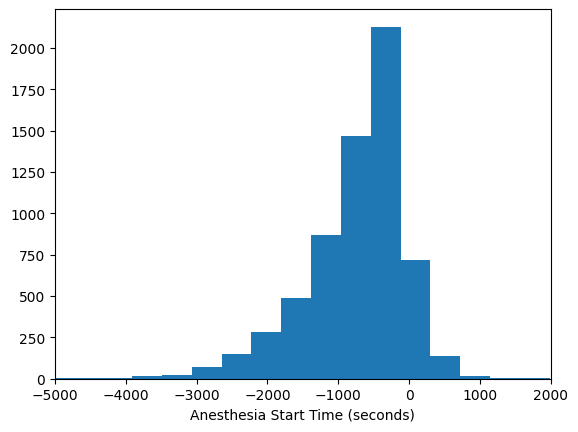

In [42]:
fig, ax = plt.subplots()
ax.hist(df_cases['anestart'], bins=50)
ax.set_xlim(-5000, 2000)
ax.set_xlabel("Anesthesia Start Time (seconds)")

Text(0.5, 0, 'Anesthesia Duration (seconds)')

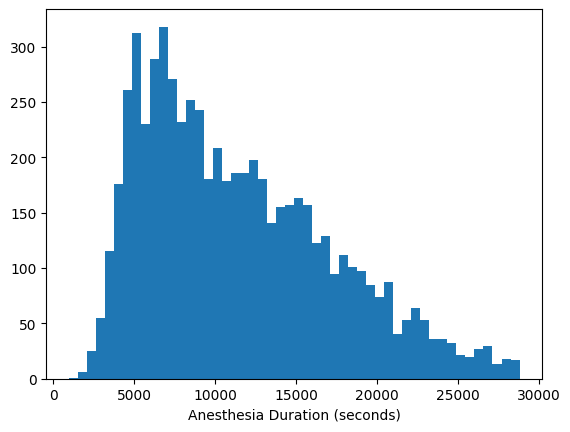

In [46]:
ane_lengths = df_cases['aneend'] - df_cases['anestart']
ane_lengths = ane_lengths[(ane_lengths <= 480*60) & (ane_lengths >= 0)]  # Filter out negative durations

fig, ax = plt.subplots()
ax.hist(ane_lengths, bins=50)
#ax.set_xlim(0, 20000)
ax.set_xlabel("Anesthesia Duration (seconds)")

## Age 

In [21]:
df_cases['age'].describe()

count    6388.000000
mean       57.296493
std        14.976461
min         0.300000
25%        48.000000
50%        59.000000
75%        68.000000
max        94.000000
Name: age, dtype: float64

Text(0.5, 0, 'Age')

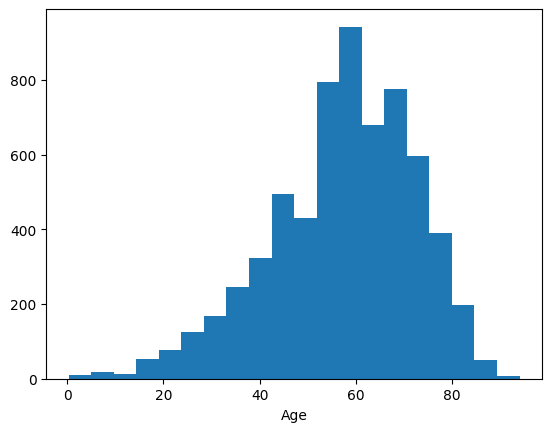

In [22]:
fig, ax = plt.subplots()
ax.hist(df_cases['age'], bins=20)
ax.set_xlabel("Age")

## Sex

In [23]:
df_cases['sex'].value_counts()

sex
M    3243
F    3145
Name: count, dtype: int64

## Height/Weight

In [24]:
df_cases['height'].describe()

count    6388.000000
mean      162.188832
std         9.905329
min        42.000000
25%       156.100000
50%       162.200000
75%       168.700000
max       188.600000
Name: height, dtype: float64

In [ ]:
df_cases['weight'].describe()

count    6388.000000
mean       61.484922
std        11.945135
min         4.800000
25%        53.300000
50%        60.500000
75%        68.700000
max       139.700000
Name: weight, dtype: float64

## ASA/Emergency Operation

- ASA I	A normal healthy patient
- ASA II	A patient with mild systemic disease
- ASA III	A patient with severe systemic disease
- ASA IV	A patient with severe systemic disease that is a constant threat to life
- ASA V	A moribund patient who is not expected to survive without the operation
- ASA VI	A declared brain-dead patient whose organs are being removed for donor purposes

In [26]:
df_cases['asa'].value_counts()

asa
2.0    3699
1.0    1792
3.0     703
4.0      48
6.0      13
Name: count, dtype: int64

In [27]:
df_cases['emop'].value_counts()

emop
0    5606
1     782
Name: count, dtype: int64

## Anesthesia Type

In [28]:
df_cases['ane_type'].value_counts()

ane_type
General            6043
Spinal              273
Sedationalgesia      72
Name: count, dtype: int64

## Post-operative ICU stay

In [30]:
df_cases['icu_days'].value_counts()


icu_days
0      5184
1       815
2        98
3        80
4        60
5        35
6        31
7        14
8         8
16        7
11        6
38        5
32        5
14        5
9         5
17        4
12        4
26        4
25        3
15        2
24        2
21        2
13        1
22        1
47        1
19        1
179       1
23        1
33        1
42        1
81        1
Name: count, dtype: int64

## Tube/Airflow complications


In [31]:
df_cases['cormack'].value_counts()

cormack
I       5178
II       235
IIIa      91
IIIb      35
IV        14
Name: count, dtype: int64

In [32]:
df_cases['airway'].value_counts()

airway
Oral            5959
Nasal              7
Tracheostomy       7
Name: count, dtype: int64

## Agent used

In [34]:
df_cases['intraop_ftn'].describe()

count    6388.000000
mean       17.043676
std        38.029277
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       200.000000
Name: intraop_ftn, dtype: float64

- intraop_ppf - hypnotic agent (propofol). Extremely important. 
- intraop_rocu / intraop_vecu — neuromuscular blockers (rocuronium, vecuronium). Relevant because they affect movement but not consciousness
- intraop_eph / intraop_phe / intraop_epi — vasopressors, indicate hemodynamic instability
- intraop_ebl / intraop_uo — blood loss and urine output, surgical stress indicators
- intraop_rbc / intraop_ffp — blood products, flags for major hemorrhage cases

In [35]:
df_filtered = df_cases[
    # Anesthesia duration 30 min to 8 hours
    ((df_cases['aneend'] - df_cases['anestart']) >= 30*60) &
    ((df_cases['aneend'] - df_cases['anestart']) <= 480*60) &

    # General anesthesia only
    (df_cases['ane_type'] == 'General') &

    # No emergency operations
    (df_cases['emop'] == 0) &

    # ASA 1-4 only
    (df_cases['asa'] <= 4) &
    (df_cases['asa'] >= 1) &

    # Less or equal to 5 ICU days 
    (df_cases['icu_days'] < 6) &

    # Must have key demographics
    (df_cases['age'].notna()) &
    (df_cases['weight'].notna()) &
    (df_cases['height'].notna()) &

    # Drug data must be present (core agents for DoA)
    # (df_cases['intraop_ppf'].notna()) &   # propofol
    # (df_cases['intraop_mdz'].notna()) &   # midazolam
    # (df_cases['intraop_ftn'].notna()) &   # fentanyl

    # Exclude difficult airways (Cormack grade 3-4)
    (df_cases['cormack'].isna() | df_cases['cormack'].isin(['I', 'II']))
]

print(df_filtered.shape)

(4976, 74)


## Collecting EEG

In [ ]:
df_trks = pd.read_csv("https://api.vitaldb.net/trks")
print(df_trks.head())
print(df_trks.columns.tolist())



   caseid         tname                                       tid
0       1       BIS/BIS  fd869e25ba82a66cc95b38ed47110bf4f14bb368
1       1  BIS/EEG1_WAV  0aa685df768489a18a5e9f53af0d83bf60890c73
2       1  BIS/EEG2_WAV  ad13b2c39b19193c8ae4a2de4f8315f18d61a57e
3       1       BIS/EMG  2525603efe18d982764dbca457affe7a45e766a9
4       1       BIS/SEF  1c91aec859304840dec75acf4a35da78be0e8ef0
['caseid', 'tname', 'tid']


In [55]:
# How many of your filtered cases have raw EEG?
filtered_caseids = df_filtered['caseid'].tolist()

eeg_cases = df_trks[
    (df_trks['tname'] == 'BIS/EEG1_WAV') &
    (df_trks['caseid'].isin(filtered_caseids))
]['caseid'].unique()

print(f"Filtered cases: {len(filtered_caseids)}")
print(f"Filtered cases with EEG: {len(eeg_cases)}")

# Your final pool - filtered cases that have EEG
eeg_case_pool = df_filtered[df_filtered['caseid'].isin(eeg_cases)]
print(f"Final pool: {len(eeg_case_pool)} cases")

# Sample 100 reproducibly
np.random.seed(42)
sample_100 = eeg_case_pool.sample(20)
sample_caseids = sample_100['caseid'].tolist()

Filtered cases: 4976
Filtered cases with EEG: 4626
Final pool: 4626 cases


In [ ]:
# Test on a single case first
test_case = sample_caseids[0]
data = vitaldb.load_case(test_case, ['BIS/EEG1_WAV', 'BIS/BIS'], interval=1/128)

print(data.shape)
print(data[:10])



(557561, 2)
[[54.15000153         nan]
 [50.54999924         nan]
 [52.59999847         nan]
 [53.59999847         nan]
 [57.25               nan]
 [60.65000153         nan]
 [59.15000153         nan]
 [57.                 nan]
 [55.5                nan]
 [56.54999924 97.09999847]]


In [58]:
print("Col 0 stats:", np.nanmin(data[:,0]), np.nanmax(data[:,0]), np.nanmean(data[:,0]))
print("Col 1 stats:", np.nanmin(data[:,1]), np.nanmax(data[:,1]), np.nanmean(data[:,1]))

Col 0 stats: -1472.6500244140625 1595.8499755859375 24.330841189096063
Col 1 stats: 0.0 97.69999694824219 60.09444426964794


In [ ]:
from scipy.signal import welch, butter, filtfilt
import numpy as np

def quick_preprocess(eeg, bis, fs=128, epoch_sec=8, amp_thresh=150):
    """
    Quick preprocessing - bandpass, epoch, basic artifact rejection, welch PSD
    Returns: (features, labels) arrays
    """
    # 1. Bandpass filter 0.5-40 Hz
    b, a = butter(4, [0.5, 40], btype='band', fs=fs)
    eeg_filt = filtfilt(b, a, eeg[~np.isnan(eeg)])
    bis_clean = bis[~np.isnan(eeg)]  # align BIS to same mask

    # 2. Epoch
    #Each epoch has the length sampling rate * sec per epoch
    epoch_len = epoch_sec * fs
    #Number of epochs is total length of signal divided by epoch length
    n_epochs = len(eeg_filt) // epoch_len
    
    features, labels = [], []
    for i in range(n_epochs):
        epoch = eeg_filt[i*epoch_len:(i+1)*epoch_len]
        bis_epoch = bis_clean[i*epoch_len:(i+1)*epoch_len]
        
        # 3. Basic artifact rejection
        #reject if amplitude exceeds threshold (simple but effective for gross artifacts)
        if np.max(np.abs(epoch)) > amp_thresh:
            continue
        
        # 4. Welch transformation to Power Frequency Domain
        freqs, psd = welch(epoch, fs=fs, nperseg=fs*2)
        
        # 5. Band powers only (keep it small)
        bands = {
            'delta': (0.5, 4),
            'theta': (4, 8),
            'alpha': (8, 13),
            'beta':  (13, 30)
        }
        band_powers = []
        for low, high in bands.values():
            idx = (freqs >= low) & (freqs < high)
            band_powers.append(np.mean(psd[idx]))
        
        # 6. Label = median BIS over epoch (skip if mostly NaN)
        bis_median = np.nanmedian(bis_epoch)
        if np.isnan(bis_median):
            continue
        
        features.append(band_powers)
        labels.append(bis_median)
    
    return np.array(features), np.array(labels)

In [60]:
all_features, all_labels, all_caseids = [], [], []

for caseid in sample_caseids:
    try:
        data = vitaldb.load_case(caseid, ['BIS/EEG1_WAV', 'BIS/BIS'], interval=1/128)
        eeg = data[:, 0]
        bis = data[:, 1]
        
        feats, labs = quick_preprocess(eeg, bis)
        if len(feats) == 0:
            continue
        
        all_features.append(feats)
        all_labels.append(labs)
        all_caseids.extend([caseid] * len(feats))
        print(f"Case {caseid}: {len(feats)} epochs")
    except Exception as e:
        print(f"Case {caseid} failed: {e}")

X = np.concatenate(all_features)
y = np.concatenate(all_labels)
print(f"Total: {X.shape}, labels: {y.shape}")

Case 4569: 501 epochs
Case 1422: 1559 epochs
Case 3168: 735 epochs
Case 3676: 936 epochs
Case 46: 1222 epochs
Case 1715: 832 epochs
Case 3232: 1551 epochs
Case 1930: 1018 epochs
Case 877: 466 epochs
Case 260: 551 epochs
Case 3063: 543 epochs
Case 655: 1913 epochs
Case 5080: 1142 epochs
Case 800: 1573 epochs
Case 5620: 1491 epochs
Case 1497: 1833 epochs
Case 817: 1336 epochs
Case 4689: 697 epochs
Case 3350: 451 epochs
Case 3062: 1342 epochs
Total: (21692, 4), labels: (21692,)


In [ ]:
# import pyarrow
# import fastparquet

# df_sample = pd.DataFrame(X, columns=['delta', 'theta', 'alpha', 'beta'])
# df_sample['bis'] = y
# df_sample['caseid'] = all_caseids

# df_sample.to_parquet('eeg_sample.parquet', engine='fastparquet')

# # Load back
# df_sample = pd.read_parquet('eeg_sample.parquet')

ArrowKeyError: A type extension with name pandas.period already defined

In [66]:
df_sample = pd.DataFrame(X, columns=['delta', 'theta', 'alpha', 'beta'])
df_sample['bis'] = y
df_sample['caseid'] = all_caseids

df_sample.to_csv('eeg_sample.csv', index=False)